In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

In [2]:
df=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"].isnull().sum()

np.int64(11)

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [11]:
df.duplicated().sum()

np.int64(0)

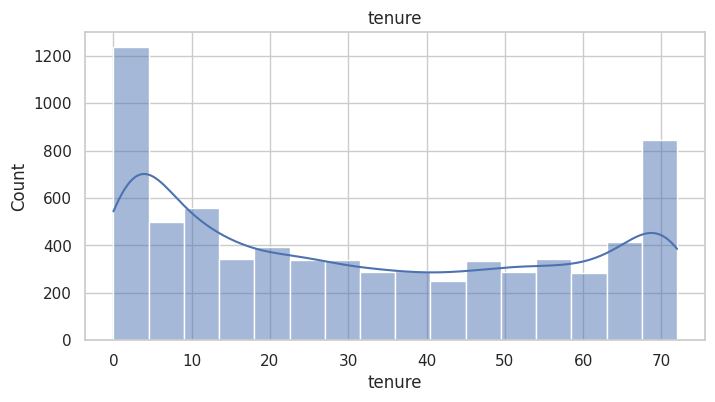

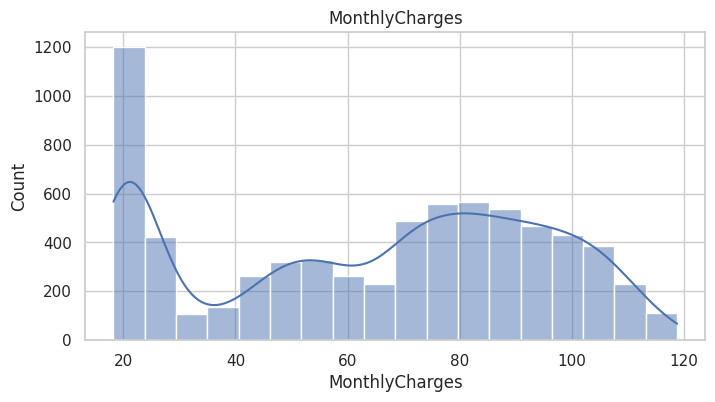

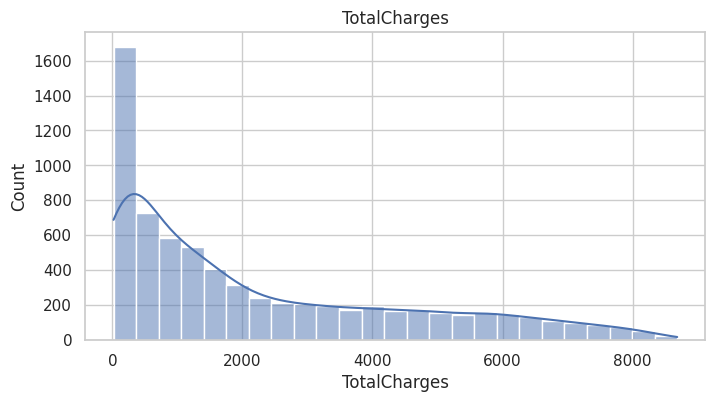

In [12]:
numerical = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numerical:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

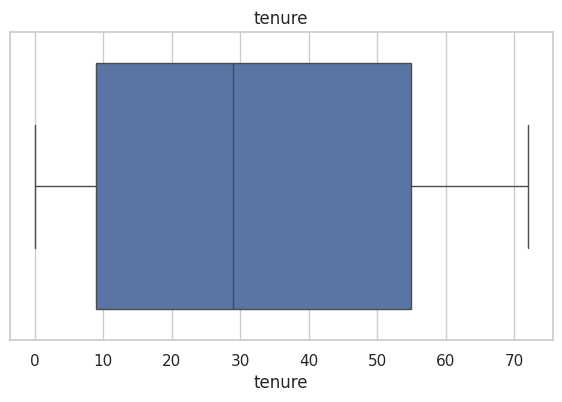

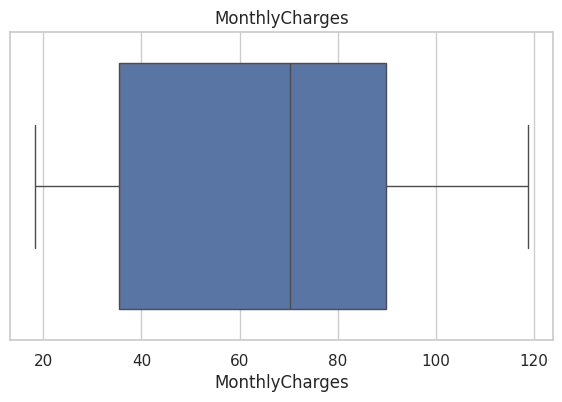

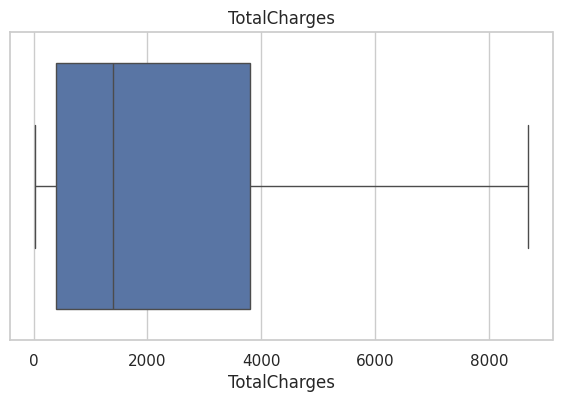

In [13]:
for col in numerical:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

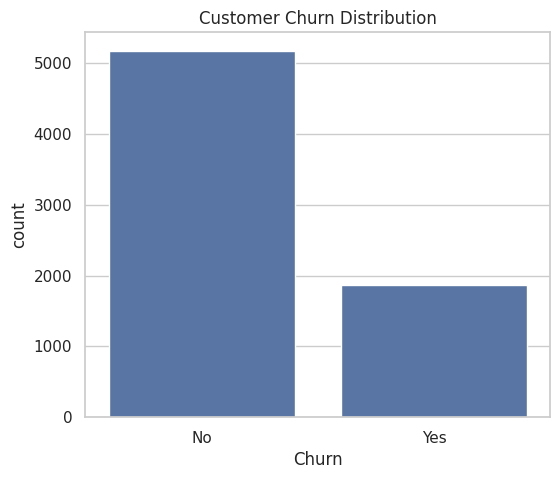

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [21]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.show()
print(df["Churn"].value_counts())
print()
print(df["Churn"].value_counts(normalize=True)*100)

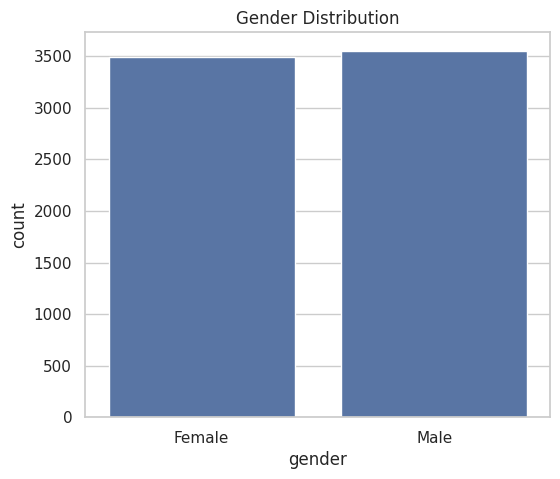

In [15]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="gender")
plt.title("Gender Distribution")
plt.show()

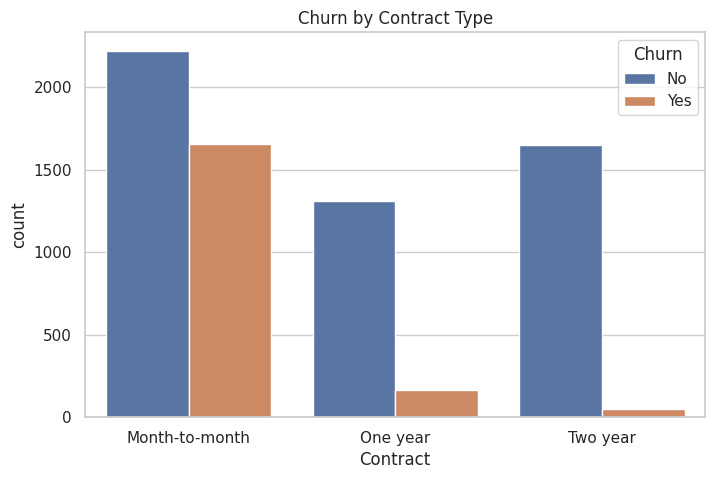

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title("Churn by Contract Type")
plt.show()

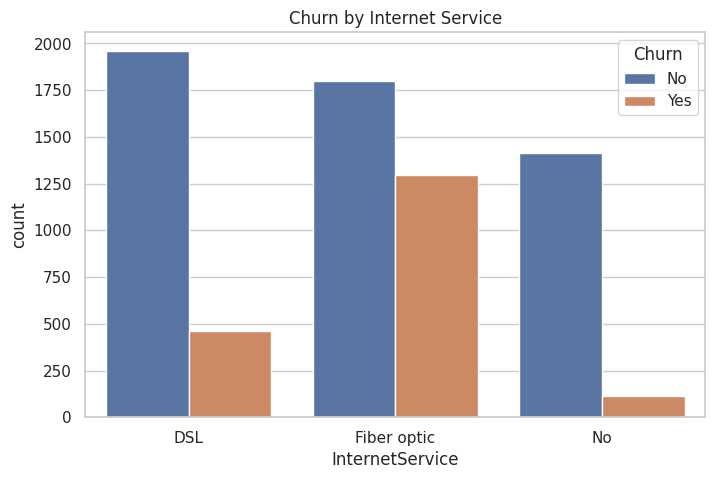

In [33]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title("Churn by Internet Service")
plt.show()

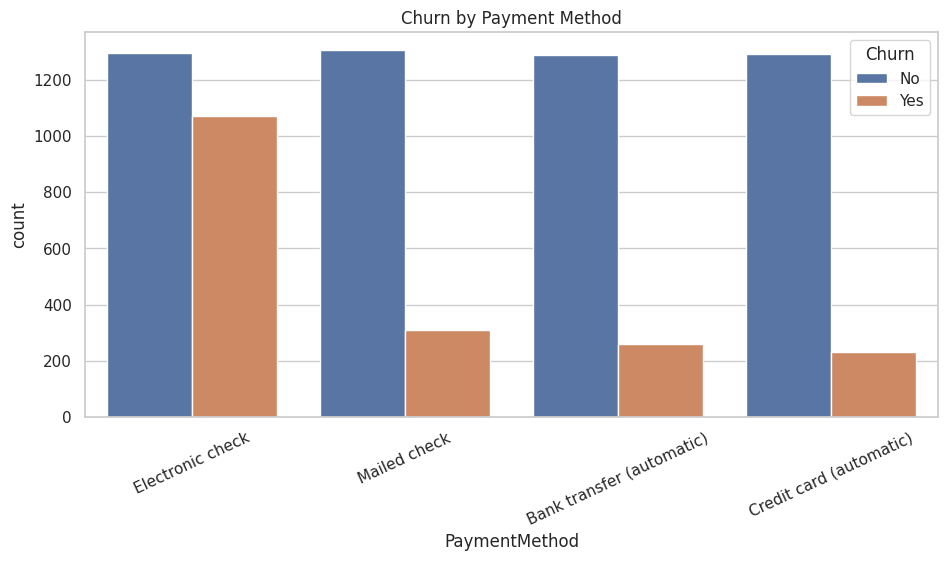

In [34]:
plt.figure(figsize=(11,5))
sns.countplot(data=df,
              x='PaymentMethod',
              hue='Churn')

plt.xticks(rotation=25)
plt.title("Churn by Payment Method")
plt.show()

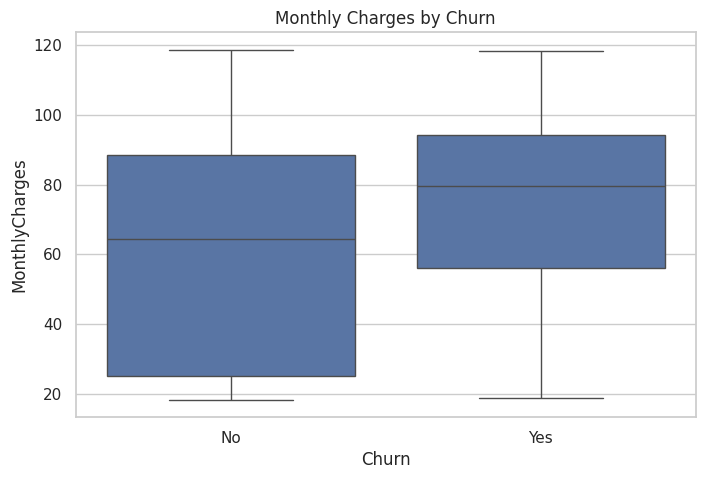

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,
            x='Churn',
            y='MonthlyCharges')

plt.title("Monthly Charges by Churn")
plt.show()

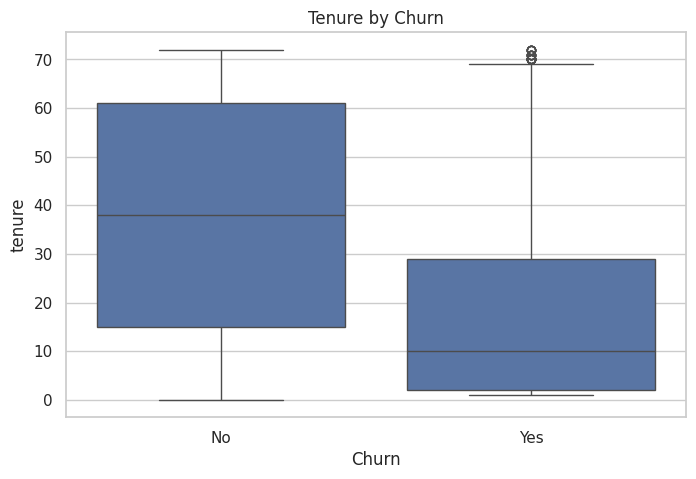

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,
            x='Churn',
            y='tenure')

plt.title("Tenure by Churn")
plt.show()

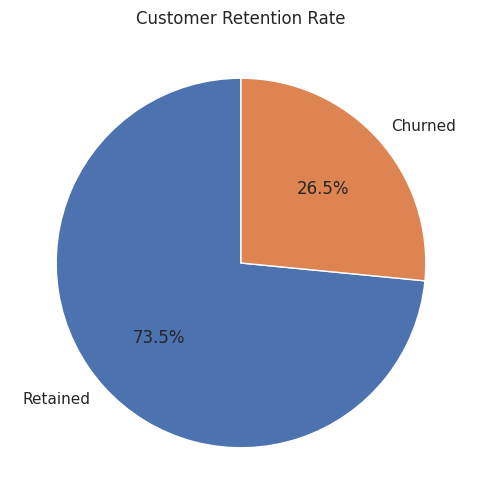

In [37]:
counts = df['Churn'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(counts,
        labels=['Retained','Churned'],
        autopct='%1.1f%%',
        startangle=90)

plt.title("Customer Retention Rate")
plt.show()

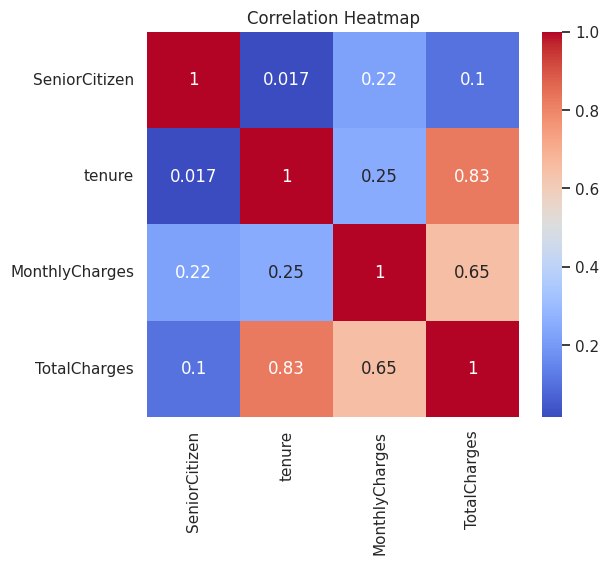

In [38]:
corr = df.select_dtypes(include=['int64','float64']).corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [39]:
total_customers = len(df)
churn_rate = (df['Churn']=='Yes').mean()*100
retention_rate = (df['Churn']=='No').mean()*100
avg_monthly = df['MonthlyCharges'].mean()
print("Total Customers :", total_customers)
print("Churn Rate :", round(churn_rate,2),"%")
print("Retention Rate :", round(retention_rate,2),"%")
print("Average Monthly Charges :", round(avg_monthly,2))

Total Customers : 7043
Churn Rate : 26.54 %
Retention Rate : 73.46 %
Average Monthly Charges : 64.76
